##***YASH KHAMKAR - 221A030***

#***Experiment 1: Implementing a simple grid-world environment and training an agent using basic Q-learning***

##***Teach taxi to pick up and drop passengers to their locations***

##***1. Import dependencies***

In [ ]:
#YASH KHAMKAR - 221A030
import os
import gymnasium as gym
import numpy as np

##***2. Load Environment***

In [ ]:
#YASH KHAMKAR - 221A030
env=gym.make('Taxi-v3',render_mode='rgb_array')

In [ ]:
#YASH KHAMKAR - 221A030
state=env.reset()

In [ ]:
#YASH KHAMKAR - 221A030
state

(53, {'prob': 1.0, 'action_mask': array([1, 0, 1, 0, 0, 0], dtype=int8)})

In [ ]:
#YASH KHAMKAR - 221A030
env.observation_space.n

np.int64(500)

In [ ]:
#YASH KHAMKAR - 221A030
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
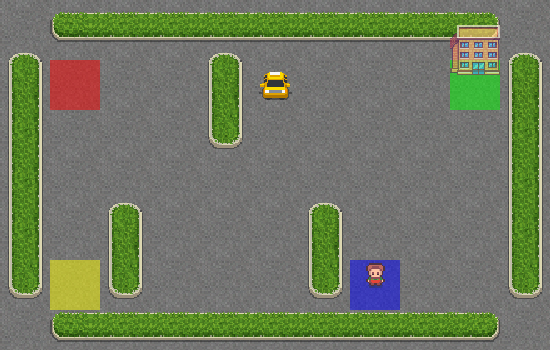

In [ ]:
#YASH KHAMKAR - 221A030
env.render()

##***3. Possible actions are down(0), up(1), right(2), left(3), pick-up(4) and drop-off(5)***

In [ ]:
#YASH KHAMKAR - 221A030
env.step(5)

(73,
 -10,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 0, 1, 1, 0, 0], dtype=int8)})

##***Here for action 5, the reward is -10. It means the agent is getting seriously penalized for the action taken.***

In [ ]:
#YASH KHAMKAR - 221A030
n_states=env.observation_space.n
n_actions=env.action_space.n

In [ ]:
#YASH KHAMKAR - 221A030
n_actions

np.int64(6)

In [ ]:
#YASH KHAMKAR - 221A030
n_states

np.int64(500)

In [ ]:
#YASH KHAMKAR - 221A030
env.env.s=452

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
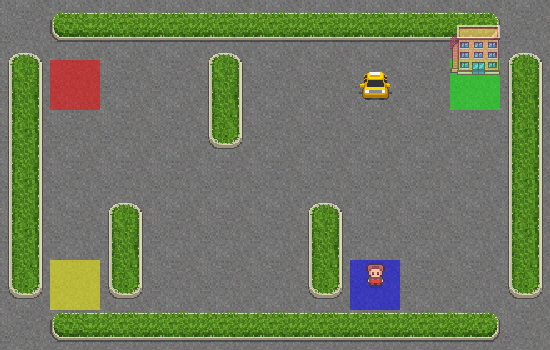

In [ ]:
#YASH KHAMKAR - 221A030
env.render()

##***4. How good does behaving completely random do?***

In [ ]:
#YASH KHAMKAR - 221A030
state=env.reset()
counter=0
g=0
reward=None
while reward!=20:
  state,reward,terminated,truncated,info=env.step(env.action_space.sample())
  counter+=1
  g+=reward
print('No. of steps taken: ',counter)

No. of steps taken:  1452


In [ ]:
#YASH KHAMKAR - 221A030
print('Total reward earned: ',g)

Total reward earned:  -5364


##***5. Let's look at just one episode and see how the Q values change after each step using the formula below***

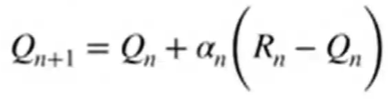

In [ ]:
#YASH KHAMKAR - 221A030
q=Q = np.zeros([n_states, n_actions])

In [ ]:
#YASH KHAMKAR - 221A030
n_actions

np.int64(6)

In [ ]:
#YASH KHAMKAR - 221A030
episodes=1
G=0
alpha=0.618

In [ ]:
#YASH KHAMKAR - 221A030
for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))
  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, done, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

Inital State 492


In [ ]:
#YASH KHAMKAR - 221A030
finalState=state

In [ ]:
#YASH KHAMKAR - 221A030
finalState

0

In [ ]:
G

-1521

##***It is clear that after one episode of Q learning, total reward is more than random approach***

##***Let's run over multuple episodes to achieve and converge to an optimal policy***

In [ ]:
#YASH KHAMKAR - 221A030
episodes = 2000
rewardTracker = []

G = 0
alpha = 0.618

for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))

  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, done, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))

Inital State 243
Inital State 43
Inital State 12
Inital State 406
Inital State 142
Inital State 482
Inital State 366
Inital State 382
Inital State 323
Inital State 22
Inital State 253
Inital State 52
Inital State 407
Inital State 6
Inital State 68
Inital State 54
Inital State 263
Inital State 172
Inital State 149
Inital State 489
Inital State 154
Inital State 411
Inital State 163
Inital State 433
Inital State 481
Inital State 427
Inital State 211
Inital State 464
Inital State 87
Inital State 294
Inital State 66
Inital State 54
Inital State 363
Inital State 89
Inital State 403
Inital State 104
Inital State 91
Inital State 32
Inital State 306
Inital State 314
Inital State 488
Inital State 53
Inital State 69
Inital State 204
Inital State 47
Inital State 367
Inital State 49
Inital State 107
Inital State 29
Inital State 283
Inital State 271
Inital State 294
Inital State 451
Inital State 23
Inital State 144
Inital State 91
Inital State 144
Inital State 6
Inital State 408
Inital State 289
Ini

##***This way, an agent learnt the optimal policy and obtained total reward 7 after 2000 episodes.***

In [ ]:
#YASH KHAMKAR - 221A030
state, _ = env.reset()
done = False

while not done:
   action = np.argmax(Q[state])
   observation, reward, terminated, truncated, _ = env.step(action)
   state = observation
   done = terminated or truncated

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
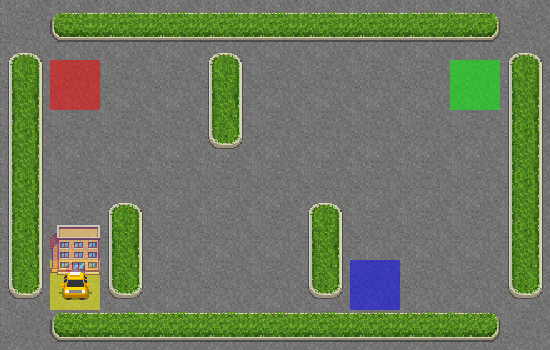

In [ ]:
#YASH KHAMKAR - 221A030
env.render()

In [ ]:
env.close()